# Intent-Based NLP Chatbot
### A rule-based chatbot using NLP preprocessing to answer queries about NLP concepts and AI applications

Install & Import Libraries

In [2]:
import nltk
import numpy as np
import random
import json
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kanak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kanak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kanak\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kanak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Step 2: Define the Intent Knowledge Base

In [3]:
intents = {
    "greeting": {
        "patterns": [
            "hello", "hi", "hey", "good morning", "good evening",
            "howdy", "what's up", "greetings", "hi there"
        ],
        "responses": [
            "Hello. I am your NLP and AI chatbot. How can I assist you?",
            "Hi. Ready to explore NLP and AI concepts?",
            "Greetings. Ask me anything about NLP or Artificial Intelligence."
        ]
    },

    "goodbye": {
        "patterns": [
            "bye", "goodbye", "see you", "exit", "quit", "take care",
            "later", "farewell", "see ya"
        ],
        "responses": [
            "Goodbye. Keep exploring AI and NLP.",
            "See you later. Continue learning.",
            "Farewell. Come back anytime with more questions."
        ]
    },

    "what_is_nlp": {
        "patterns": [
            "what is nlp", "explain nlp", "define nlp",
            "what does nlp stand for", "natural language processing"
        ],
        "responses": [
            "Natural Language Processing (NLP) is a branch of Artificial Intelligence that enables computers to understand, interpret, and generate human language.",
            "NLP focuses on enabling machines to process and analyze large amounts of natural language data."
        ]
    },

    "nlp_pipeline": {
        "patterns": [
            "nlp pipeline", "steps in nlp", "nlp workflow",
            "text processing steps", "how nlp works step by step"
        ],
        "responses": [
            "The NLP pipeline includes steps such as tokenization, stopword removal, stemming or lemmatization, vectorization, and model training.",
            "Typical NLP workflow: text preprocessing, feature extraction, model building, and evaluation."
        ]
    },

    "tokenization": {
        "patterns": [
            "what is tokenization", "tokenize text", "tokens in nlp"
        ],
        "responses": [
            "Tokenization is the process of splitting text into smaller units such as words or sentences.",
            "It is the first step in NLP where text is broken into tokens for further processing."
        ]
    },

    "stemming_lemmatization": {
        "patterns": [
            "stemming vs lemmatization", "what is stemming",
            "what is lemmatization"
        ],
        "responses": [
            "Stemming reduces words to their root form by removing suffixes, while lemmatization converts words to their base dictionary form.",
            "Lemmatization is more accurate than stemming because it considers context and vocabulary."
        ]
    },

    "stopwords": {
        "patterns": [
            "what are stopwords", "stopword removal"
        ],
        "responses": [
            "Stopwords are common words such as 'the', 'is', and 'and' that carry little meaning and are often removed during preprocessing.",
            "Removing stopwords helps reduce noise and improves model efficiency."
        ]
    },

    "tfidf": {
        "patterns": [
            "what is tfidf", "tf idf explanation"
        ],
        "responses": [
            "TF-IDF measures how important a word is in a document relative to a corpus.",
            "It is calculated as the product of term frequency and inverse document frequency."
        ]
    },

    "bag_of_words": {
        "patterns": [
            "bag of words", "bow model", "what is bag of words"
        ],
        "responses": [
            "Bag of Words is a text representation method that converts text into a vector of word counts.",
            "It ignores grammar and word order but keeps frequency information."
        ]
    },

    "ngrams": {
        "patterns": [
            "what are ngrams", "bigram trigram", "n gram model"
        ],
        "responses": [
            "N-grams are sequences of N words used for language modeling.",
            "Examples include unigrams, bigrams, and trigrams."
        ]
    },

    "word_embeddings": {
        "patterns": [
            "word embeddings", "word2vec", "glove", "word vectors"
        ],
        "responses": [
            "Word embeddings represent words as dense vectors capturing semantic meaning.",
            "Similar words have similar vector representations in embedding space."
        ]
    },

    "cosine_similarity": {
        "patterns": [
            "cosine similarity", "similarity between vectors"
        ],
        "responses": [
            "Cosine similarity measures the angle between two vectors to determine similarity.",
            "It is widely used in NLP to compare word embeddings."
        ]
    },

    "named_entity_recognition": {
        "patterns": [
            "what is ner", "named entity recognition"
        ],
        "responses": [
            "Named Entity Recognition identifies entities such as persons, locations, and organizations in text.",
            "It is used in information extraction and knowledge graph construction."
        ]
    },

    "pos_tagging": {
        "patterns": [
            "pos tagging", "part of speech tagging"
        ],
        "responses": [
            "POS tagging assigns grammatical labels such as noun, verb, and adjective to words.",
            "It helps understand sentence structure."
        ]
    },

    "sentiment_analysis": {
        "patterns": [
            "sentiment analysis", "opinion mining"
        ],
        "responses": [
            "Sentiment analysis classifies text as positive, negative, or neutral.",
            "It is widely used in product reviews and social media analysis."
        ]
    },

    "transformers": {
        "patterns": [
            "transformer model", "bert", "gpt", "attention mechanism"
        ],
        "responses": [
            "Transformers use attention mechanisms to process sequences in parallel.",
            "They power modern NLP models like BERT and GPT."
        ]
    },

    "what_is_ai": {
        "patterns": [
            "what is ai", "define artificial intelligence"
        ],
        "responses": [
            "Artificial Intelligence refers to machines that simulate human intelligence.",
            "It includes learning, reasoning, and problem-solving capabilities."
        ]
    },

    "machine_learning": {
        "patterns": [
            "machine learning", "types of machine learning"
        ],
        "responses": [
            "Machine Learning is a subset of AI where systems learn patterns from data.",
            "It includes supervised, unsupervised, and reinforcement learning."
        ]
    },

    "deep_learning": {
        "patterns": [
            "deep learning", "neural networks"
        ],
        "responses": [
            "Deep Learning uses neural networks with multiple layers to learn complex patterns.",
            "It is used in image recognition, speech processing, and NLP."
        ]
    },

    "ai_applications": {
        "patterns": [
            "applications of ai", "uses of ai"
        ],
        "responses": [
            "AI is used in healthcare, finance, transportation, and natural language processing.",
            "Examples include recommendation systems, fraud detection, and chatbots."
        ]
    },

    "nlp_applications": {
        "patterns": [
            "applications of nlp", "where is nlp used"
        ],
        "responses": [
            "NLP is used in chatbots, machine translation, sentiment analysis, and speech recognition.",
            "It powers applications like virtual assistants and text summarization."
        ]
    },

    "chatbot": {
        "patterns": [
            "what is a chatbot", "how chatbots work"
        ],
        "responses": [
            "A chatbot is a system that simulates human conversation.",
            "It can be rule-based or powered by machine learning models."
        ]
    },

    "thanks": {
        "patterns": [
            "thanks", "thank you", "helpful"
        ],
        "responses": [
            "You are welcome.",
            "Glad I could help.",
            "Feel free to ask more questions."
        ]
    }
}
print(f"Knowledge base loaded with {len(intents)} intents!")
print("Intents:", list(intents.keys()))

Knowledge base loaded with 23 intents!
Intents: ['greeting', 'goodbye', 'what_is_nlp', 'nlp_pipeline', 'tokenization', 'stemming_lemmatization', 'stopwords', 'tfidf', 'bag_of_words', 'ngrams', 'word_embeddings', 'cosine_similarity', 'named_entity_recognition', 'pos_tagging', 'sentiment_analysis', 'transformers', 'what_is_ai', 'machine_learning', 'deep_learning', 'ai_applications', 'nlp_applications', 'chatbot', 'thanks']


NLP Preprocessing Pipeline

In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove special characters
    3. Tokenize
    4. Remove stopwords
    5. Lemmatize
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove special characters (keep letters, numbers, spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # Step 3: Tokenize
    tokens = word_tokenize(text)

    # Step 4: Remove stopwords (keep important question words)
    keep_words = {'what', 'how', 'why', 'when', 'where', 'who', 'which', 'is', 'are'}
    tokens = [t for t in tokens if t not in stop_words or t in keep_words]

    # Step 5: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Test the preprocessing pipeline
sample = "What are the applications of Natural Language Processing?"
print(f"Original : {sample}")
print(f"Processed: {preprocess(sample)}")

Original : What are the applications of Natural Language Processing?
Processed: what are application natural language processing


Build the Intent Classifier (TF-IDF + Cosine Similarity)

In [5]:
class NLPChatbot:
    def __init__(self, intents, threshold=0.15):
        self.intents = intents
        self.threshold = threshold
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.pattern_corpus = []
        self.pattern_labels = []

        self._build_index()
        print(f"Chatbot initialized with {len(self.pattern_corpus)} training patterns!")

    def _build_index(self):
        """Build TF-IDF index from all intent patterns."""
        for intent_name, data in self.intents.items():
            for pattern in data['patterns']:
                self.pattern_corpus.append(preprocess(pattern))
                self.pattern_labels.append(intent_name)

        self.tfidf_matrix = self.vectorizer.fit_transform(self.pattern_corpus)

    def predict_intent(self, user_input):
        """Find the best matching intent using cosine similarity."""
        processed_input = preprocess(user_input)
        input_vector = self.vectorizer.transform([processed_input])

        similarities = cosine_similarity(input_vector, self.tfidf_matrix).flatten()
        best_idx = np.argmax(similarities)
        best_score = similarities[best_idx]

        if best_score >= self.threshold:
            return self.pattern_labels[best_idx], best_score
        return None, best_score

    def respond(self, user_input):
        """Generate a response for the user input."""
        intent, confidence = self.predict_intent(user_input)

        if intent:
            response = random.choice(self.intents[intent]['responses'])
            return response, intent, confidence
        else:
            fallbacks = [
                "I'm not sure about that. Try asking about NLP concepts (tokenization, TF-IDF, embeddings) or AI topics!",
                "Hmm, I didn't quite catch that. Ask me about NLP, Machine Learning, Deep Learning, or AI applications!",
                "I specialize in NLP & AI topics. Try: 'What is tokenization?' or 'Explain transformers'"
            ]
            return random.choice(fallbacks), "unknown", confidence


# Initialize the chatbot
bot = NLPChatbot(intents)

Chatbot initialized with 75 training patterns!


Sample Conversations

In [6]:
def demo_conversation(queries):
    """Display a formatted demo conversation."""
    print("=" * 65)
    print("           🤖  NLP Chatbot — Sample Conversation")
    print("=" * 65)
    for query in queries:
        response, intent, confidence = bot.respond(query)
        print(f"\n You   : {query}")
        print(f" Bot   : {response}")
        print(f"   [Intent: {intent} | Confidence: {confidence:.2f}]")
    print("\n" + "=" * 65)


# --- Conversation 1: NLP Concepts ---
print("\n CONVERSATION 1: NLP Concepts\n")
demo_conversation([
    "Hello!",
    "What is NLP?",
    "How does tokenization work?",
    "What is TF-IDF?",
    "Explain word embeddings",
    "What are stopwords?",
    "Thanks!"
])


 CONVERSATION 1: NLP Concepts

           🤖  NLP Chatbot — Sample Conversation

 You   : Hello!
 Bot   : Greetings. Ask me anything about NLP or Artificial Intelligence.
   [Intent: greeting | Confidence: 1.00]

 You   : What is NLP?
 Bot   : NLP focuses on enabling machines to process and analyze large amounts of natural language data.
   [Intent: what_is_nlp | Confidence: 1.00]

 You   : How does tokenization work?
 Bot   : It can be rule-based or powered by machine learning models.
   [Intent: chatbot | Confidence: 0.47]

 You   : What is TF-IDF?
 Bot   : It is calculated as the product of term frequency and inverse document frequency.
   [Intent: tfidf | Confidence: 1.00]

 You   : Explain word embeddings
 Bot   : Word embeddings represent words as dense vectors capturing semantic meaning.
   [Intent: word_embeddings | Confidence: 0.85]

 You   : What are stopwords?
 Bot   : Stopwords are common words such as 'the', 'is', and 'and' that carry little meaning and are often removed d

In [7]:
# --- Conversation 2: AI & Deep Learning ---
print("\nCONVERSATION 2: AI Applications & Deep Learning\n")
demo_conversation([
    "Hi there!",
    "What is artificial intelligence?",
    "Explain machine learning",
    "What are neural networks?",
    "Tell me about transformers and BERT",
    "What are the applications of AI?",
    "How do chatbots work?",
    "Goodbye!"
])


CONVERSATION 2: AI Applications & Deep Learning

           🤖  NLP Chatbot — Sample Conversation

 You   : Hi there!
 Bot   : Greetings. Ask me anything about NLP or Artificial Intelligence.
   [Intent: greeting | Confidence: 1.00]

 You   : What is artificial intelligence?
 Bot   : It includes learning, reasoning, and problem-solving capabilities.
   [Intent: what_is_ai | Confidence: 0.67]

 You   : Explain machine learning
 Bot   : It includes supervised, unsupervised, and reinforcement learning.
   [Intent: machine_learning | Confidence: 0.84]

 You   : What are neural networks?
 Bot   : It is used in image recognition, speech processing, and NLP.
   [Intent: deep_learning | Confidence: 0.77]

 You   : Tell me about transformers and BERT
 Bot   : Transformers use attention mechanisms to process sequences in parallel.
   [Intent: transformers | Confidence: 0.71]

 You   : What are the applications of AI?
 Bot   : AI is used in healthcare, finance, transportation, and natural languag

In [8]:
# --- Conversation 3: Advanced NLP ---
print("\nCONVERSATION 3: Advanced NLP Topics\n")
demo_conversation([
    "Hey!",
    "What is sentiment analysis?",
    "What is named entity recognition?",
    "Stemming vs lemmatization — what's the difference?",
    "Explain self attention",
    "How does GPT work?",
    "What is AI used for in healthcare?"
])


CONVERSATION 3: Advanced NLP Topics

           🤖  NLP Chatbot — Sample Conversation

 You   : Hey!
 Bot   : Greetings. Ask me anything about NLP or Artificial Intelligence.
   [Intent: greeting | Confidence: 1.00]

 You   : What is sentiment analysis?
 Bot   : Sentiment analysis classifies text as positive, negative, or neutral.
   [Intent: sentiment_analysis | Confidence: 0.85]

 You   : What is named entity recognition?
 Bot   : Named Entity Recognition identifies entities such as persons, locations, and organizations in text.
   [Intent: named_entity_recognition | Confidence: 0.90]

 You   : Stemming vs lemmatization — what's the difference?
 Bot   : Stemming reduces words to their root form by removing suffixes, while lemmatization converts words to their base dictionary form.
   [Intent: stemming_lemmatization | Confidence: 0.85]

 You   : Explain self attention
 Bot   : Natural Language Processing (NLP) is a branch of Artificial Intelligence that enables computers to understand

Step 6: Interactive Chat Mode

Chatbot Evaluation & Confidence Analysis

Query                                         Expected                  Predicted                   Conf ✓/✗
-------------------------------------------------------------------------------------------------------------------
What is natural language processing?          what_is_nlp               what_is_nlp                 0.90 ✅
Explain how tokenization works                tokenization              chatbot                     0.40 ❌
Tell me about word2vec                        word_embeddings           word_embeddings             1.00 ✅
What does BERT do?                            transformers              transformers                0.86 ✅
How does sentiment analysis work?             sentiment_analysis        sentiment_analysis          0.80 ✅
What is machine learning?                     machine_learning          machine_learning            0.82 ✅
Applications of artificial intelligence       ai_applications           what_is_ai                  0.70 ❌
Hello!                    

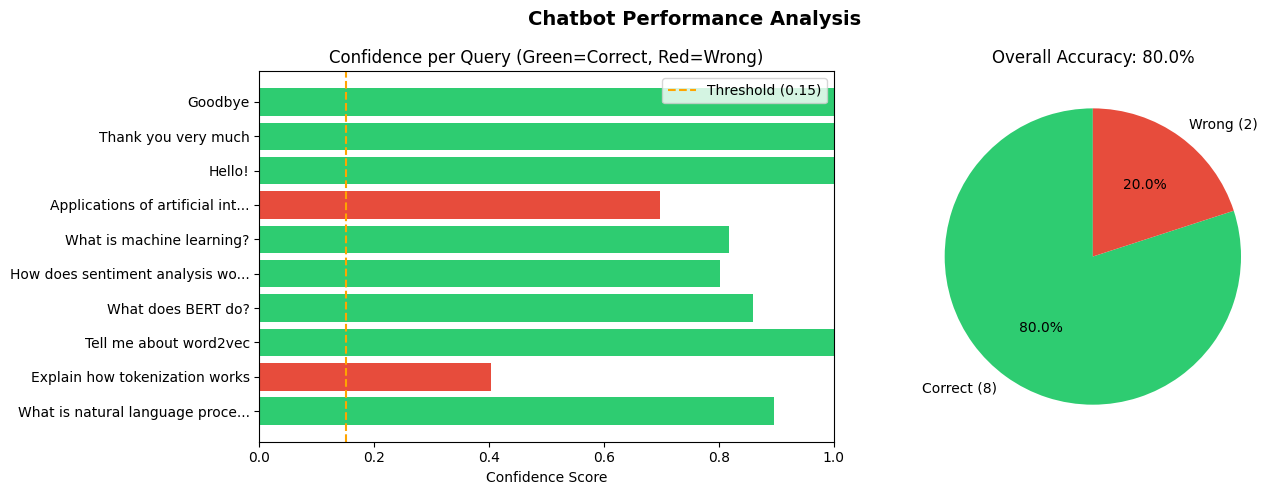

📊 Evaluation chart saved as chatbot_evaluation.png


In [9]:
import matplotlib.pyplot as plt

# Test queries with expected intents
test_cases = [
    ("What is natural language processing?", "what_is_nlp"),
    ("Explain how tokenization works", "tokenization"),
    ("Tell me about word2vec", "word_embeddings"),
    ("What does BERT do?", "transformers"),
    ("How does sentiment analysis work?", "sentiment_analysis"),
    ("What is machine learning?", "machine_learning"),
    ("Applications of artificial intelligence", "ai_applications"),
    ("Hello!", "greeting"),
    ("Thank you very much", "thanks"),
    ("Goodbye", "goodbye"),
]

results = []
correct = 0

print(f"{'Query':<45} {'Expected':<25} {'Predicted':<25} {'Conf':>6} {'✓/✗'}")
print("-" * 115)

for query, expected in test_cases:
    _, predicted, confidence = bot.respond(query)
    is_correct = predicted == expected
    correct += is_correct
    results.append(confidence)
    status = "✅" if is_correct else "❌"
    print(f"{query:<45} {expected:<25} {predicted:<25} {confidence:>6.2f} {status}")

accuracy = correct / len(test_cases) * 100
print(f"\n🎯 Accuracy: {correct}/{len(test_cases)} = {accuracy:.1f}%")

# Plot confidence scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chatbot Performance Analysis', fontsize=14, fontweight='bold')

queries_short = [q[:30] + '...' if len(q) > 30 else q for q, _ in test_cases]
colors = ['#2ecc71' if (bot.respond(q)[1] == e) else '#e74c3c' for q, e in test_cases]

axes[0].barh(queries_short, results, color=colors)
axes[0].axvline(x=0.15, color='orange', linestyle='--', label='Threshold (0.15)')
axes[0].set_xlabel('Confidence Score')
axes[0].set_title('Confidence per Query (Green=Correct, Red=Wrong)')
axes[0].legend()
axes[0].set_xlim(0, 1)

axes[1].pie([correct, len(test_cases) - correct],
            labels=[f'Correct ({correct})', f'Wrong ({len(test_cases)-correct})'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Overall Accuracy: {accuracy:.1f}%')

plt.tight_layout()
plt.savefig('chatbot_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 Evaluation chart saved as chatbot_evaluation.png")

## 🗺️ Step 8: NLP Pipeline Summary

```
User Input
    │
    ▼
┌─────────────────────────────────────────────┐
│           NLP Preprocessing                 │
│  Lowercase → Remove Special Chars           │
│  → Tokenize → Remove Stopwords              │
│  → Lemmatize                                │
└──────────────────┬──────────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────────┐
│           TF-IDF Vectorization              │
│   Convert processed text to numeric vectors │
└──────────────────┬──────────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────────┐
│       Cosine Similarity Matching            │
│   Compare query vector vs pattern vectors   │
└──────────────────┬──────────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────────┐
│         Intent Classification               │
│   Best match above threshold → Intent       │
└──────────────────┬──────────────────────────┘
                   │
                   ▼
         Random Response Selection
                   │
                   ▼
              Bot Response
```

### 📌 Key Components Used
| Component | Library | Purpose |
|-----------|---------|--------|
| Tokenization | NLTK | Split text into words |
| Stopword Removal | NLTK | Remove noise words |
| Lemmatization | NLTK WordNet | Reduce words to base form |
| TF-IDF Vectorization | scikit-learn | Numeric representation |
| Cosine Similarity | scikit-learn | Intent matching |
| Random Response | Python | Variety in replies |